# German Credit Dataset Preprocessing

The goal is to preprocess the German Credit dataset similar to Adult Census and COMPAS:
- Binary protected attributes (sex, age)
- Binary target variable (credit risk)
- Drop unnecessary columns

In [23]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

## Load the dataset

In [24]:
dataset_path = '../GermanCredit/german_credit_data.csv'
df = pd.read_csv(dataset_path)
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [25]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Shape: (1000, 11)

Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk']

Data types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
Risk                object
dtype: object


In [26]:
# Check for missing values
print("Missing values:")
print(df.isna().sum())

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [27]:
# Check unique values for key columns
for col in ['Sex', 'Age', 'Risk', 'Job', 'Housing']:
    print(f"{col}: {df[col].unique()}")

Sex: ['male' 'female']
Age: [67 22 49 45 53 35 61 28 25 24 60 32 44 31 48 26 36 39 42 34 63 27 30 57
 33 37 58 23 29 52 50 46 51 41 40 66 47 56 54 20 21 38 70 65 74 68 43 55
 64 75 19 62 59]
Risk: ['good' 'bad']
Job: [2 1 3 0]
Housing: ['own' 'free' 'rent']


## Preprocessing

In [28]:
# Drop the index column if present
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [29]:
# Drop rows with missing values (primarily in Saving accounts and Checking account)
print(f"Rows before dropping NA: {len(df)}")
df = df.dropna()
print(f"Rows after dropping NA: {len(df)}")

Rows before dropping NA: 1000
Rows after dropping NA: 522


### Encode Target Variable: Risk
- 0 = good (no risk / good credit)
- 1 = bad (risky / bad credit)

In [30]:
# Binary encode Risk (target variable)
# 0 = good credit, 1 = bad credit
df['risk'] = df['Risk'].replace({'good': 0, 'bad': 1})
df = df.drop(columns=['Risk'])
df.head()

C:\Users\raulv\AppData\Local\Temp\ipykernel_41380\1246383311.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['risk'] = df['Risk'].replace({'good': 0, 'bad': 1})


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,risk
1,22,female,2,own,little,moderate,5951,48,radio/TV,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,0
4,53,male,2,free,little,little,4870,24,car,1
7,35,male,3,rent,little,moderate,6948,36,car,0
9,28,male,3,own,little,moderate,5234,30,car,1


### Encode Protected Attribute: Sex
- 0 = Female
- 1 = Male

In [31]:
# Binary encode Sex: 0 = Female, 1 = Male
df['sex'] = df['Sex'].replace({'female': 0, 'male': 1})
df = df.drop(columns=['Sex'])
df.head()

C:\Users\raulv\AppData\Local\Temp\ipykernel_41380\3393299776.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['sex'] = df['Sex'].replace({'female': 0, 'male': 1})


,Age,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,risk,sex
1,22,2,own,little,moderate,5951,48,radio/TV,1,0
3,45,2,free,little,little,7882,42,furniture/equipment,0,1
4,53,2,free,little,little,4870,24,car,1,1
7,35,3,rent,little,moderate,6948,36,car,0,1
9,28,3,own,little,moderate,5234,30,car,1,1


### Encode Protected Attribute: Age
- 0 = Young (age <= 35)
- 1 = Adult/Old (age > 35)

In [32]:
# Binary encode Age: 0 = Young (<=35), 1 = Adult (>35)
# This is consistent with Adult Census and COMPAS preprocessing
df['age'] = df['Age'].apply(lambda x: 0 if x <= 35 else 1)
df = df.drop(columns=['Age'])
df.head()

,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,risk,sex,age
1,2,own,little,moderate,5951,48,radio/TV,1,0,0
3,2,free,little,little,7882,42,furniture/equipment,0,1,1
4,2,free,little,little,4870,24,car,1,1,1
7,3,rent,little,moderate,6948,36,car,0,1,0
9,3,own,little,moderate,5234,30,car,1,1,0


### Encode Job (skill level)
Keep original numeric values (0-3):
- 0 = unskilled non-resident
- 1 = unskilled resident  
- 2 = skilled
- 3 = highly skilled

In [33]:
# Keep Job as-is (already numeric 0-3)
# Job: 0=unskilled non-resident, 1=unskilled resident, 2=skilled, 3=highly skilled
df['job'] = df['Job']
df = df.drop(columns=['Job'])
print(f"Job unique values: {df['job'].unique()}")
df.head()

Job unique values: [2 3 1 0]


,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,risk,sex,age,job
1,own,little,moderate,5951,48,radio/TV,1,0,0,2
3,free,little,little,7882,42,furniture/equipment,0,1,1,2
4,free,little,little,4870,24,car,1,1,1,2
7,rent,little,moderate,6948,36,car,0,1,0,3
9,own,little,moderate,5234,30,car,1,1,0,3


### Encode Housing
Use LabelEncoder to preserve categories:
- 0 = free
- 1 = own
- 2 = rent

In [34]:
# Encode Housing using LabelEncoder (keeps all 3 categories)
encoder = LabelEncoder()
df['housing'] = encoder.fit_transform(df['Housing'])
housing_mapping = {category: code for code, category in enumerate(encoder.classes_)}
print("Housing mapping:", housing_mapping)
df = df.drop(columns=['Housing'])
df.head()

Housing mapping: {'free': 0, 'own': 1, 'rent': 2}


,Saving accounts,Checking account,Credit amount,Duration,Purpose,risk,sex,age,job,housing
1,little,moderate,5951,48,radio/TV,1,0,0,2,1
3,little,little,7882,42,furniture/equipment,0,1,1,2,0
4,little,little,4870,24,car,1,1,1,2,0
7,little,moderate,6948,36,car,0,1,0,3,2
9,little,moderate,5234,30,car,1,1,0,3,1


### Encode Saving Accounts
Use LabelEncoder to preserve categories:
- 0 = little
- 1 = moderate
- 2 = quite rich
- 3 = rich

In [35]:
# Encode Saving accounts using LabelEncoder (keeps all 4 categories)
encoder = LabelEncoder()
df['savings'] = encoder.fit_transform(df['Saving accounts'])
savings_mapping = {category: code for code, category in enumerate(encoder.classes_)}
print("Savings mapping:", savings_mapping)
df = df.drop(columns=['Saving accounts'])
df.head()

Savings mapping: {'little': 0, 'moderate': 1, 'quite rich': 2, 'rich': 3}


,Checking account,Credit amount,Duration,Purpose,risk,sex,age,job,housing,savings
1,moderate,5951,48,radio/TV,1,0,0,2,1,0
3,little,7882,42,furniture/equipment,0,1,1,2,0,0
4,little,4870,24,car,1,1,1,2,0,0
7,moderate,6948,36,car,0,1,0,3,2,0
9,moderate,5234,30,car,1,1,0,3,1,0


### Encode Checking Account
Use LabelEncoder to preserve categories:
- 0 = little
- 1 = moderate
- 2 = rich

In [36]:
# Encode Checking account using LabelEncoder (keeps all 3 categories)
encoder = LabelEncoder()
df['checking'] = encoder.fit_transform(df['Checking account'])
checking_mapping = {category: code for code, category in enumerate(encoder.classes_)}
print("Checking mapping:", checking_mapping)
df = df.drop(columns=['Checking account'])
df.head()

Checking mapping: {'little': 0, 'moderate': 1, 'rich': 2}


,Credit amount,Duration,Purpose,risk,sex,age,job,housing,savings,checking
1,5951,48,radio/TV,1,0,0,2,1,0,1
3,7882,42,furniture/equipment,0,1,1,2,0,0,0
4,4870,24,car,1,1,1,2,0,0,0
7,6948,36,car,0,1,0,3,2,0,1
9,5234,30,car,1,1,0,3,1,0,1


### Encode Purpose (loan purpose)
Keep as numeric encoding using LabelEncoder

In [37]:
# Encode Purpose using LabelEncoder
encoder = LabelEncoder()
df['purpose'] = encoder.fit_transform(df['Purpose'])
purpose_mapping = {category: code for code, category in enumerate(encoder.classes_)}
print("Purpose mapping:", purpose_mapping)
df = df.drop(columns=['Purpose'])
df.head()

Purpose mapping: {'business': 0, 'car': 1, 'domestic appliances': 2, 'education': 3, 'furniture/equipment': 4, 'radio/TV': 5, 'repairs': 6, 'vacation/others': 7}


,Credit amount,Duration,risk,sex,age,job,housing,savings,checking,purpose
1,5951,48,1,0,0,2,1,0,1,5
3,7882,42,0,1,1,2,0,0,0,4
4,4870,24,1,1,1,2,0,0,0,1
7,6948,36,0,1,0,3,2,0,1,1
9,5234,30,1,1,0,3,1,0,1,1


### Rename remaining columns

In [38]:
# Rename columns to lowercase for consistency
df = df.rename(columns={
    'Credit amount': 'credit_amount',
    'Duration': 'duration'
})
df.head()

,credit_amount,duration,risk,sex,age,job,housing,savings,checking,purpose
1,5951,48,1,0,0,2,1,0,1,5
3,7882,42,0,1,1,2,0,0,0,4
4,4870,24,1,1,1,2,0,0,0,1
7,6948,36,0,1,0,3,2,0,1,1
9,5234,30,1,1,0,3,1,0,1,1


### Reorder columns
Put protected attributes first, then features, then target

In [39]:
# Reorder columns: protected attributes first, then other features, then target
column_order = ['age', 'sex', 'job', 'housing', 'savings', 'checking', 'credit_amount', 'duration', 'purpose', 'risk']
df = df[column_order]
df.head()

,age,sex,job,housing,savings,checking,credit_amount,duration,purpose,risk
1,0,0,2,1,0,1,5951,48,5,1
3,1,1,2,0,0,0,7882,42,4,0
4,1,1,2,0,0,0,4870,24,1,1
7,0,1,3,2,0,1,6948,36,1,0
9,0,1,3,1,0,1,5234,30,1,1


In [40]:
# Verify the preprocessing
print("Final shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nProtected attributes unique values:")
print(f"age: {df['age'].unique()}")
print(f"sex: {df['sex'].unique()}")
print(f"\nTarget variable:")
print(f"risk: {df['risk'].unique()}")
print(f"\nTarget distribution:")
print(df['risk'].value_counts())

Final shape: (522, 10)

Column types:
age              int64
sex              int64
job              int64
housing          int64
savings          int64
checking         int64
credit_amount    int64
duration         int64
purpose          int64
risk             int64
dtype: object

Protected attributes unique values:
age: [0 1]
sex: [0 1]

Target variable:
risk: [1 0]

Target distribution:
risk
0    291
1    231
Name: count, dtype: int64


## Save Preprocessed Dataset

In [41]:
output_path = '../GermanCredit/german-preprocessed-binary.csv'
df.to_csv(output_path, sep=',', index=False, encoding='utf-8')
print(f"Saved preprocessed dataset to: {output_path}")

Saved preprocessed dataset to: ../GermanCredit/german-preprocessed-binary.csv


## Summary

**Protected Attributes (binary):**
- `age`: 0 = young (≤35), 1 = adult (>35)
- `sex`: 0 = female, 1 = male

**Target Variable:**
- `risk`: 0 = good credit, 1 = bad credit

**Other Features (categorical, NOT binary):**
- `job`: 0-3 (unskilled non-resident → highly skilled)
- `housing`: 0 = free, 1 = own, 2 = rent
- `savings`: 0 = little, 1 = moderate, 2 = quite rich, 3 = rich
- `checking`: 0 = little, 1 = moderate, 2 = rich
- `purpose`: 0-7 (various loan purposes)

**Mapping Dictionary (for protected attributes in experiments):**
```python
mapping = {
    'age': {
        0: 'young',
        1: 'adult'
    },
    'sex': {
        0: 'female',
        1: 'male'
    }
}
protected_attributes = ['age', 'sex']
target_variable = 'risk'
```

## Distribution Analysis

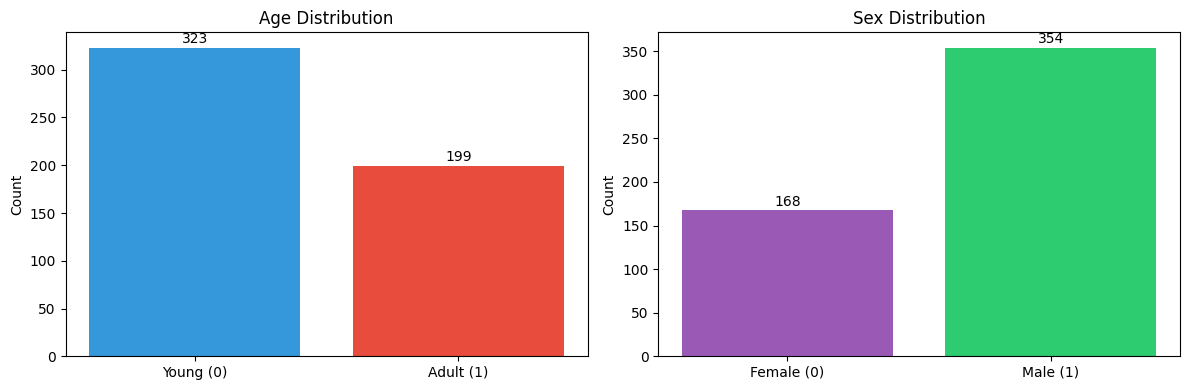

In [42]:
import matplotlib.pyplot as plt

# Distribution of protected attributes
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
age_counts = df['age'].value_counts().sort_index()
axes[0].bar(['Young (0)', 'Adult (1)'], age_counts.values, color=['#3498db', '#e74c3c'])
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(age_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center')

# Sex distribution
sex_counts = df['sex'].value_counts().sort_index()
axes[1].bar(['Female (0)', 'Male (1)'], sex_counts.values, color=['#9b59b6', '#2ecc71'])
axes[1].set_title('Sex Distribution')
axes[1].set_ylabel('Count')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center')

plt.tight_layout()
plt.show()

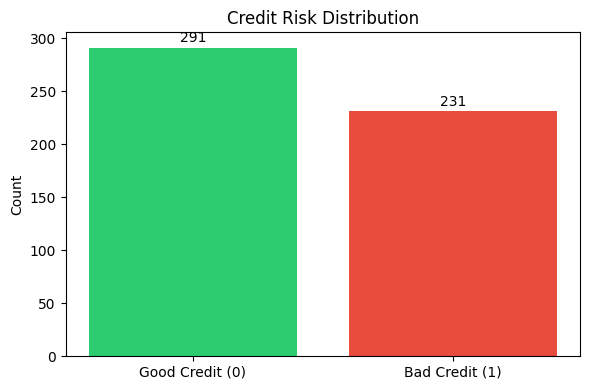

In [43]:
# Target distribution
risk_counts = df['risk'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(['Good Credit (0)', 'Bad Credit (1)'], risk_counts.values, color=['#2ecc71', '#e74c3c'])
plt.title('Credit Risk Distribution')
plt.ylabel('Count')
for i, v in enumerate(risk_counts.values):
    plt.text(i, v + 5, str(v), ha='center')
plt.tight_layout()
plt.show()

In [44]:
# Cross-tabulation of sex-age with risk
df['sex-age'] = df['sex'].astype(str) + df['age'].astype(str)
crosstab = pd.crosstab(df['sex-age'], df['risk'])
print("Cross-tabulation of sex-age subgroups with risk:")
print(crosstab)
df = df.drop(columns=['sex-age'])

Cross-tabulation of sex-age subgroups with risk:
risk       0   1
sex-age         
00        53  67
01        33  15
10       116  87
11        89  62
